In [1]:
import xarray as xr 
import glob
import torch 
import matplotlib.pyplot as plt
import numpy as np
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import numpy as np

def leading_eof1(X):
    # Remove time mean
    X_anom = X - np.mean(X, axis=0, keepdims=True)

    # Covariance in vertical/space dimension
    C = np.cov(X_anom, rowvar=False)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(C)

    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Leading EOF and PC
    eof1 = eigvecs[:, 0]
    pc1 = X_anom @ eof1

    return eof1, pc1, eigvals[0] / np.sum(eigvals)

def leading_eof2(X):
    # Remove time mean
    X_anom = X - np.mean(X, axis=0, keepdims=True)

    # Covariance in vertical/space dimension
    C = np.cov(X_anom, rowvar=False)

    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(C)

    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Leading EOF and PC
    eof2 = eigvecs[:, 1]
    pc2 = X_anom @ eof2

    return eof2, pc2, eigvals[0] / np.sum(eigvals)

In [3]:
# IG = np.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-02-15/tensor_steps24_parrallel_lev00020_lat00149_lon00096.npy')

In [5]:
# IG_s = IG.squeeze()

# # Largest absolute gradient anywhere in each level
# level_abs_max = np.nanmax(np.abs(IG_s), axis=(1, 2))

# # Top 5 levels, sorted from largest to smaller
# top5_levels = np.argsort(level_abs_max)[-5:][::-1]

# for rank, lev in enumerate(top5_levels, start=1):
#     ilat, ilon = np.unravel_index(
#         np.nanargmax(np.abs(IG_s[lev, :, :])),
#         IG_s[lev, :, :].shape,
#     )

#     signed_value = IG_s[lev, ilat, ilon]
#     abs_value = np.abs(signed_value)

#     print(f"Rank {rank}")
#     print("Level:", lev)
#     print("Signed value:", signed_value)
#     print("Absolute value:", abs_value)
#     print("Lat index:", ilat)
#     print("Lon index:", ilon)
#     print()

In [2]:
DATE = '1981-01-15'

DS = xr.open_dataset('/glade/work/wchapman/b.e21.BHIST.f09_g17_Seasonal_Stochai_b050_025_1980.cam.h1.2010-10-13-00000.nc') 
lat = DS["lat"].values if hasattr(DS["lat"], "values") else DS["lat"]
lon = DS["lon"].values if hasattr(DS["lon"], "values") else DS["lon"]

dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"+DATE+"/"
files = sorted(glob.glob(dir_o+"tensor_steps24_parrallel_lev00020_lat*.npy"))
stacked = np.stack([np.load(f).squeeze()[20+32+32-4].squeeze() for f in files])

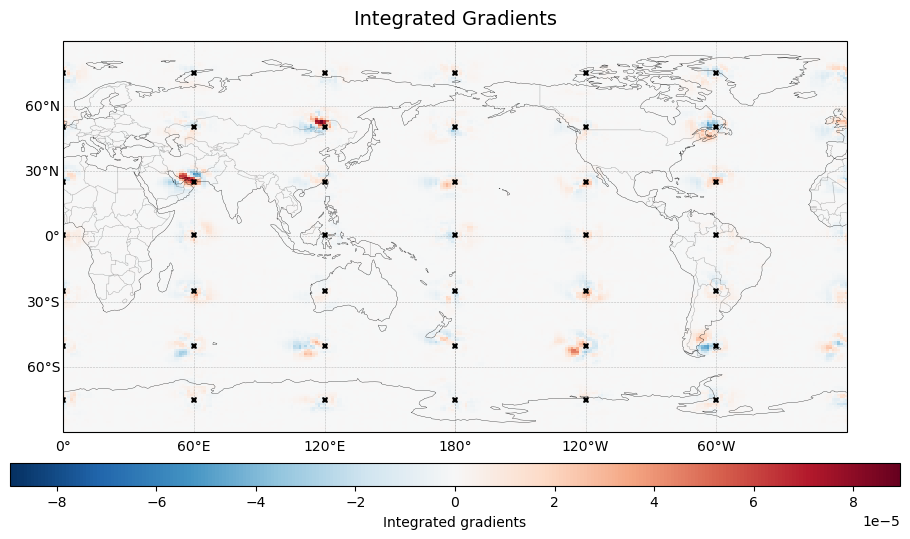

In [3]:
mean_IG = np.mean(stacked, axis=0)

# IG = np.load(dir_o + "tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy").squeeze()
# field_show = IG[20, :, :].squeeze()

# field_cyc, lon_cyc = add_cyclic_point(field_show, coord=lon)
field_cyc, lon_cyc = add_cyclic_point(mean_IG, coord=lon)

vmax = np.nanmax(np.abs(field_cyc))
vmin = -vmax

fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

im = ax.pcolormesh(
    lon_cyc,
    lat,
    field_cyc,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Integrated gradients")

ax.set_title("Integrated Gradients", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

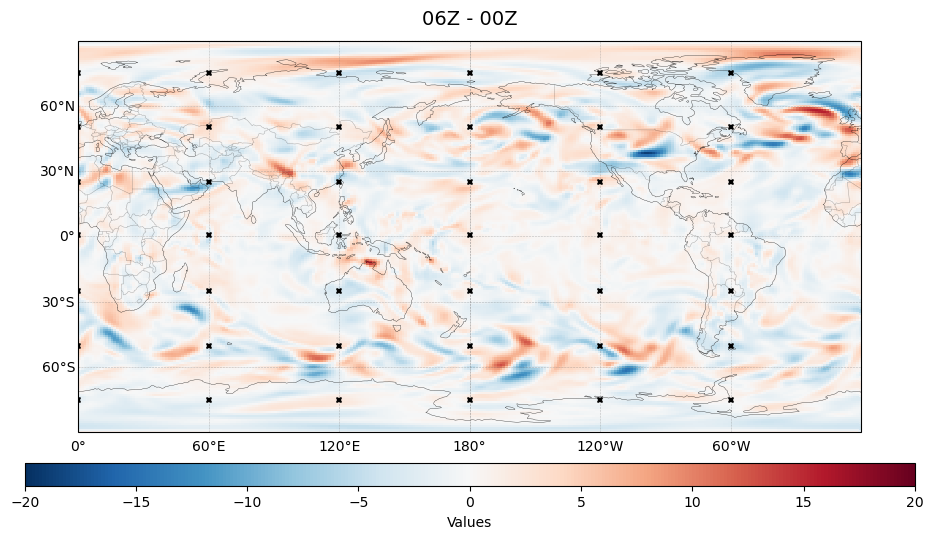

In [6]:
# Difference in values between 00Z and 006Z
t1 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_'+DATE+'_00_00_00_be21_condition_tensor.pth').squeeze().numpy()
t2 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_'+DATE+'_06_00_00_be21_condition_tensor.pth').squeeze().numpy()


fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
vmin=-20; vmax=20
im = ax.pcolormesh(
    lon_cyc,
    lat,
    t2[20,:,:]-t1[20,:,:],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Values")

ax.set_title("06Z - 00Z", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

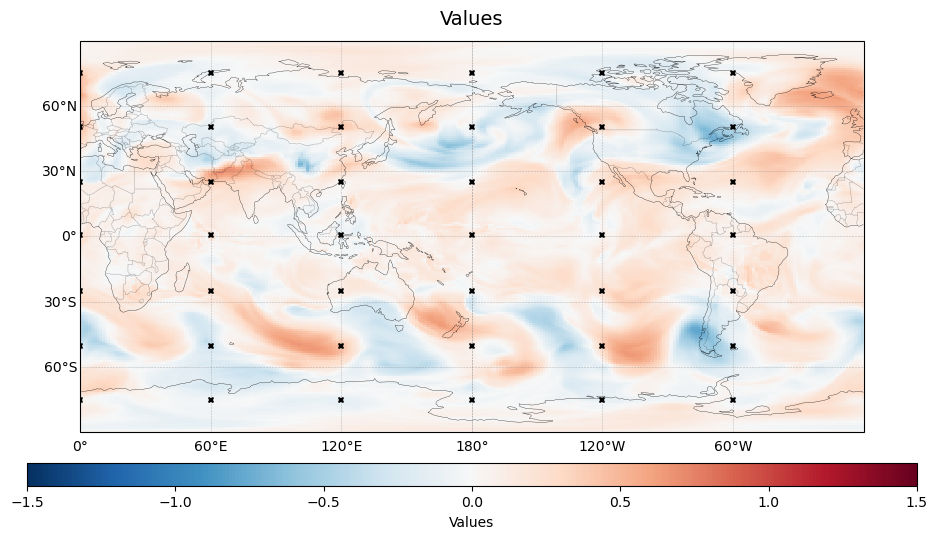

In [10]:
# Difference in values between 00Z and associated climatology
climo = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_1981-'+DATE[5:]+'_00_00_00_be21_condition_tensor_baseline.pth').squeeze().numpy()
t1 = torch.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_'+DATE+'_00_00_00_be21_condition_tensor.pth').squeeze().numpy()


fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
vmin=-1.5; vmax=1.5
im = ax.pcolormesh(
    lon_cyc,
    lat,
    t1[17+64,:,:]-climo[17+64,:,:],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Values")

ax.set_title("Values", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [51]:
# input concatenated tensor's indexes for each input variable

# U = input_tensor[0:32]
# V = input_tensor[32:64]
# T = input_tensor[64:96]
# Q = input_tensor[96:128]

# TREFHT = input_tensor[129]
# PS = input_tensor[128]

# co2mr_3d = input_tensor[-1]
# ICEFRAC = input_tensor[-2]
# SST = input_tensor[-3]
# SOLIN = input_tensor[-4]
# LANDM_COSLAT = input_tensor[-5]
# z_norm = input_tensor[-6]

In [3]:
dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"
lat_of_interest = 25 #N
lon_of_interest = 60 #E

lat_of_interest_near = DS["lat"].sel(lat=lat_of_interest, method='nearest')
lon_of_interest_near = DS["lon"].sel(lon=lon_of_interest, method='nearest')
ilat_of_interest = np.where(lat == lat_of_interest_near.values)[0][0]
ilon_of_interest = np.where(lon == lon_of_interest_near.values)[0][0]
ilat_of_interest_str = f"{ilat_of_interest:05}"
ilon_of_interest_str = f"{ilon_of_interest:05}"

files = sorted(glob.glob(dir_o+"*/tensor_steps24_parrallel_lev00020_lat"+ilat_of_interest_str+"_lon"+ilon_of_interest_str+".npy"))[:30]
stackeddate = np.stack([np.load(f).squeeze() for f in files])

meandate_IG = np.mean(stackeddate, axis=0)

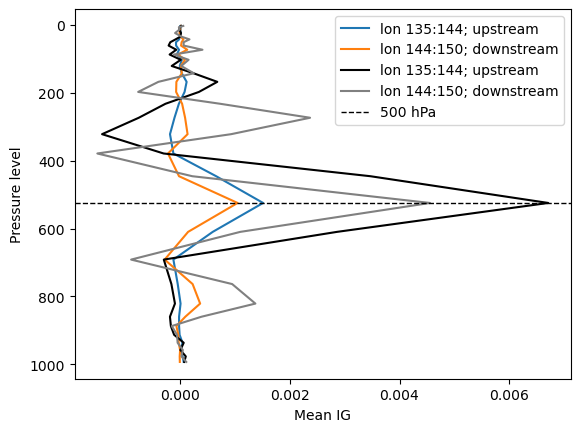

In [13]:
# U, V, T, Q: addval = 0, 32, 64, 96
addval = 0
plt.plot(
    np.mean(np.mean(meandate_IG[0+addval:32+addval, 118:126, 135:144], axis=1), axis=1),
    DS["lev"].values,
    label="lon 135:144; upstream")

plt.plot(
    np.mean(np.mean(meandate_IG[0+addval:32+addval, 118:126, 144:150], axis=1), axis=1),
    DS["lev"].values,
    label="lon 144:150; downstream")

plt.plot(
    np.mean(np.mean(stackeddate[15,0+addval:32+addval, 118:126, 135:144], axis=1), axis=1),
    DS["lev"].values,
    label="lon 135:144; upstream", color='k')

plt.plot(
    np.mean(np.mean(stackeddate[15,0+addval:32+addval, 118:126, 144:150], axis=1), axis=1),
    DS["lev"].values,
    label="lon 144:150; downstream",color='grey')


plt.axhline(
    y=524.6871747076511,
    color="k",
    linestyle="--",
    linewidth=1,
    label="500 hPa",
)

plt.gca().invert_yaxis()
plt.xlabel("Mean IG")
plt.ylabel("Pressure level")
plt.legend()

plt.show()

In [14]:
addval=64

# Upstream and downstream EOF
time_space_matrix1 = np.mean(np.mean(stackeddate[:,0+addval:32+addval, 118:126, 135:144],axis=-1),axis=-1)
time_space_matrix2 = np.mean(np.mean(stackeddate[:,0+addval:32+addval, 118:126, 144:150],axis=-1),axis=-1)

X1 = time_space_matrix1.copy()
X2 = time_space_matrix2.copy()

eof1, pc1, eigvals

eigvec1, pc1, eigval1 = leading_eof1(X1)
eigvec2, pc1, eigval2 = leading_eof1(X2)

# Sign-align downstream mode to upstream mode using temporal PCs
corr = np.corrcoef(pc1, pc2)[0, 1]

if corr < 0:
    eigvec2 = -eigvec2
    pc2 = -pc2
    corr = -corr

print("Upstream leading eigenvalue fraction:")
print(eigval1)

print("Downstream leading eigenvalue fraction:")
print(eigval2)

print("PC correlation after sign alignment:")
print(corr)

print("Upstream leading eigenvector:")
print(eigvec1)

print("Downstream leading eigenvector, temporally sign-aligned:")
print(eigvec2)

Upstream leading eigenvalue fraction:
0.5702103782178645
Downstream leading eigenvalue fraction:
0.6249441486526301
PC correlation after sign alignment:
0.8745989161550776
Upstream leading eigenvector:
[ 0.01472738  0.00743054  0.03476486 -0.01177016 -0.02309672  0.02728207
  0.03647561 -0.01821126 -0.02653398 -0.00073286 -0.01227167 -0.00265636
 -0.01363357  0.02770346  0.01017933  0.14218857  0.04873148 -0.25698591
 -0.59862774 -0.63717684 -0.20456527  0.12409845  0.13799342  0.20173799
  0.1347546   0.06441882  0.02498214  0.01672267  0.01226969  0.00719061
  0.01149347  0.00189498]
Downstream leading eigenvector, temporally sign-aligned:
[ 0.006944   -0.00864954  0.00621952  0.00203526 -0.00169729  0.00911551
  0.01227472  0.01848497  0.0344553   0.01208798  0.00549795  0.00311991
  0.03700265  0.00220813  0.01843288 -0.15229603  0.11055298  0.34064461
  0.57966515  0.4584874  -0.05860117 -0.36729061 -0.31828479 -0.23837046
 -0.03996567 -0.00696758 -0.00453527 -0.0036051   0.001450

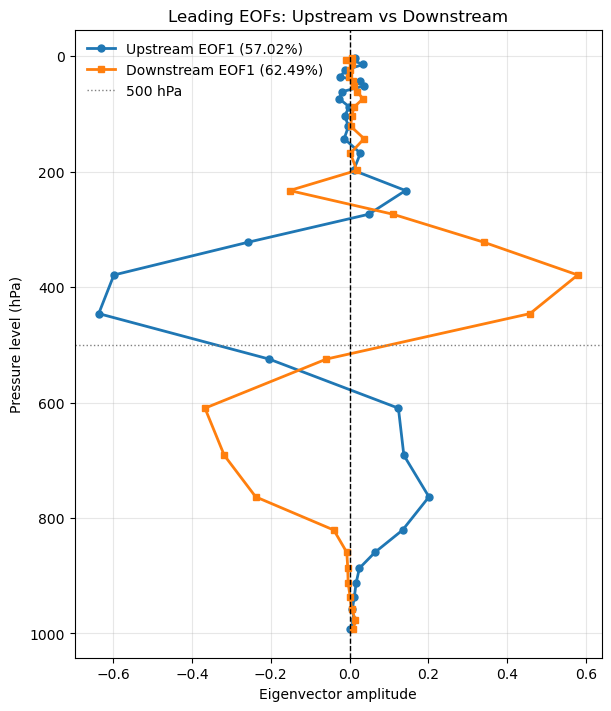

In [15]:
# Upstream and downstream EOF 1
X1 = time_space_matrix1.copy()
X2 = time_space_matrix2.copy()

eof1_up, pc_up, frac_up = leading_eof1(X1)
eof1_down, pc_down, frac_down = leading_eof1(X2)

# Sign-align downstream to upstream using temporal correlation
if np.corrcoef(pc_up, pc_down)[0, 1] < 0:
    eof1_down = -eof1_down
    pc_down = -pc_down

lev = DS["lev"].values

# Plot both on the same axes
fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)

ax.plot(
    eof1_up,
    lev,
    marker="o",
    linewidth=2,
    markersize=5,
    label=f"Upstream EOF1 ({frac_up:.2%})"
)

ax.plot(
    eof1_down,
    lev,
    marker="s",
    linewidth=2,
    markersize=5,
    label=f"Downstream EOF1 ({frac_down:.2%})"
)

ax.axvline(
    x=0,
    color="k",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=500,
    color="gray",
    linestyle=":",
    linewidth=1,
    label="500 hPa"
)

ax.invert_yaxis()
ax.set_xlabel("Eigenvector amplitude")
ax.set_ylabel("Pressure level (hPa)")
ax.set_title("Leading EOFs: Upstream vs Downstream")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.show()

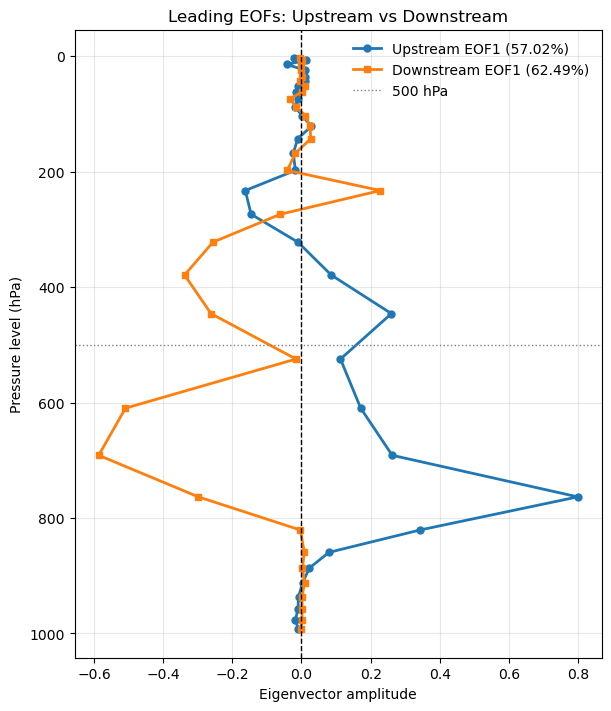

In [65]:
# Upstream and downstream EOF2
X1 = time_space_matrix1.copy()
X2 = time_space_matrix2.copy()

eof2_up, pc_up, frac_up = leading_eof2(X1)
eof2_down, pc_down, frac_down = leading_eof2(X2)

# Sign-align downstream to upstream using temporal correlation
if np.corrcoef(pc_up, pc_down)[0, 1] < 0:
    eof2_down = -eof2_down
    pc_down = -pc_down

lev = DS["lev"].values

# Plot both on the same axes
fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)

ax.plot(
    eof2_up,
    lev,
    marker="o",
    linewidth=2,
    markersize=5,
    label=f"Upstream EOF2 ({frac_up:.2%})"
)

ax.plot(
    eof2_down,
    lev,
    marker="s",
    linewidth=2,
    markersize=5,
    label=f"Downstream EOF2 ({frac_down:.2%})"
)

ax.axvline(
    x=0,
    color="k",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y=500,
    color="gray",
    linestyle=":",
    linewidth=1,
    label="500 hPa"
)

ax.invert_yaxis()
ax.set_xlabel("Eigenvector amplitude")
ax.set_ylabel("Pressure level (hPa)")
ax.set_title("Leading EOFs: Upstream vs Downstream")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.show()